In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('../data/titanic.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
df.head()

Shape: 887 rows, 8 columns

Missing values:
sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64

Duplicates: 70


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [4]:
dup_groups = (
    df[df.duplicated(keep=False)]
    .assign(row_index=lambda x: x.index)
    .sort_values(list(df.columns))
)

dup_groups

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived,row_index
466,0,0.75,3,19.2583,0,0,1,1,466
641,0,0.75,3,19.2583,0,0,1,1,641
240,0,18.00,1,15.5000,0,0,1,1,240
609,0,18.00,1,15.5000,0,0,1,1,609
262,0,21.00,0,7.7500,0,0,1,0,262
...,...,...,...,...,...,...,...,...,...
598,1,42.00,0,7.8958,0,0,1,0,598
600,1,44.00,0,8.0500,0,0,1,0,600
693,1,44.00,0,8.0500,0,0,1,0,693
251,1,62.00,0,26.5500,1,0,0,0,251


In [29]:
df[(df["sex"] == 1) & (df["age"] == 23) & (df["fare"] == 7.8958) & (df["survived"] == 0)]

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived,class,Class_Group
29,1,23.0,0,7.8958,0,0,1,0,3rd_class,Third
75,1,23.0,0,7.8958,0,0,1,0,3rd_class,Third
647,1,23.0,0,7.8958,0,0,1,0,3rd_class,Third
749,1,23.0,0,7.8958,0,0,1,0,3rd_class,Third
874,1,23.0,0,7.8958,0,0,1,0,3rd_class,Third


In [5]:
dup_summary = (
    df[df.duplicated(keep=False)]
    .groupby(list(df.columns), dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

dup_summary

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived,count
22,1,23.00,0,7.8958,0,0,1,0,5
21,1,22.00,0,8.0500,0,0,1,0,4
3,0,22.00,0,7.7500,0,0,1,1,4
11,1,19.00,0,7.8958,0,0,1,0,3
34,1,30.00,0,7.2292,0,0,1,0,3
28,1,27.00,0,7.8958,0,0,1,0,3
26,1,25.00,0,13.0000,0,1,0,0,3
23,1,23.00,0,13.0000,0,1,0,0,3
37,1,30.00,0,13.0000,0,1,0,0,3
42,1,34.00,0,8.0500,0,0,1,0,3


In [6]:
print("--- Dataset Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
df.describe()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB

--- Descriptive Statistics ---


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


In [7]:
df.dtypes

sex              int64
age            float64
family_size      int64
fare           float64
1st_class        int64
2nd_class        int64
3rd_class        int64
survived         int64
dtype: object

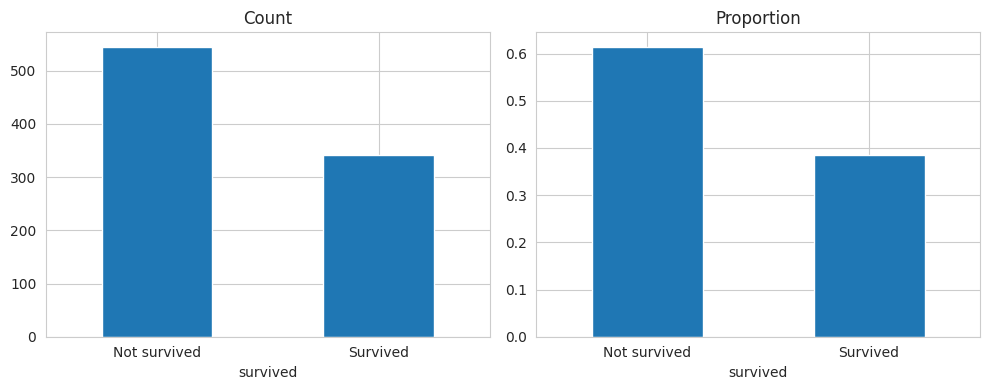

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['survived'].value_counts().plot.bar(ax=axes[0])
axes[0].set_title('Count')
axes[0].set_xticklabels(['Not survived', 'Survived'], rotation=0)

df['survived'].value_counts(normalize=True).plot.bar(ax=axes[1])
axes[1].set_title('Proportion')
axes[1].set_xticklabels(['Not survived', 'Survived'], rotation=0)

plt.tight_layout()
plt.show()

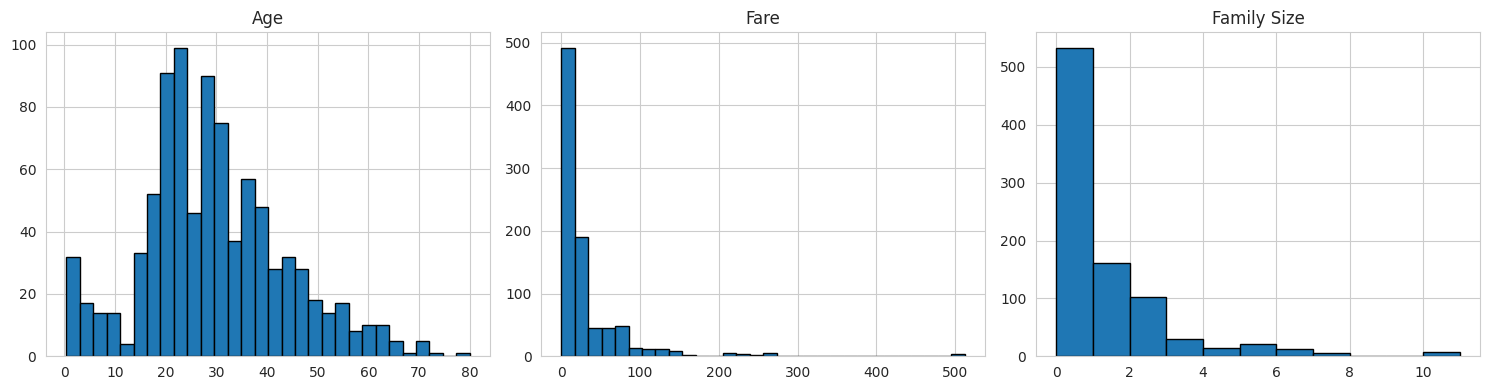

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['age'].hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Age')

df['fare'].hist(bins=30, ax=axes[1], edgecolor='black')
axes[1].set_title('Fare')

df['family_size'].hist(bins=range(0, 12), ax=axes[2], edgecolor='black')
axes[2].set_title('Family Size')

plt.tight_layout()
plt.show()

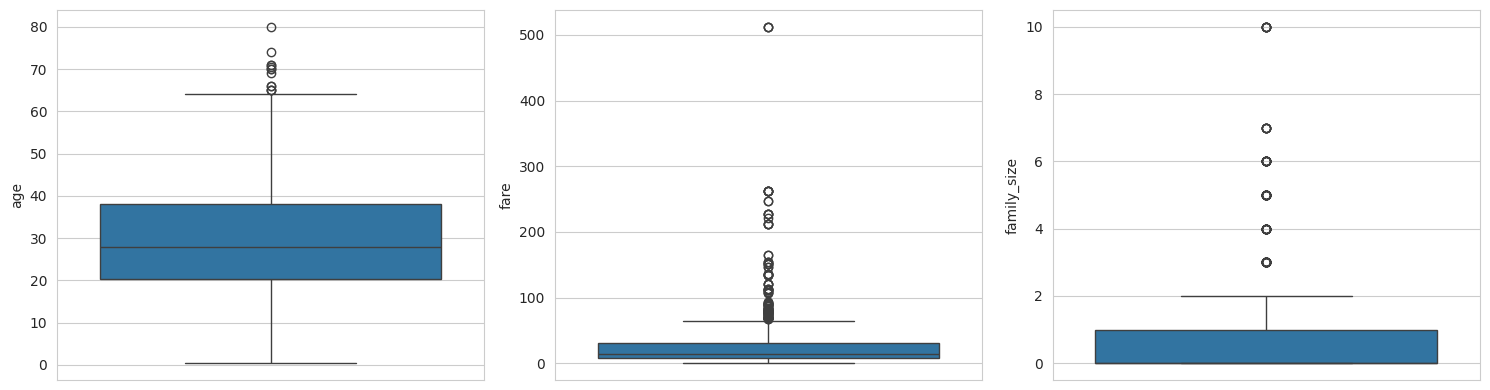

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.dtypes
sns.boxplot(y=df['age'], ax=axes[0])
sns.boxplot(y=df['fare'], ax=axes[1])
sns.boxplot(y=df['family_size'], ax=axes[2])

plt.tight_layout()
plt.show()

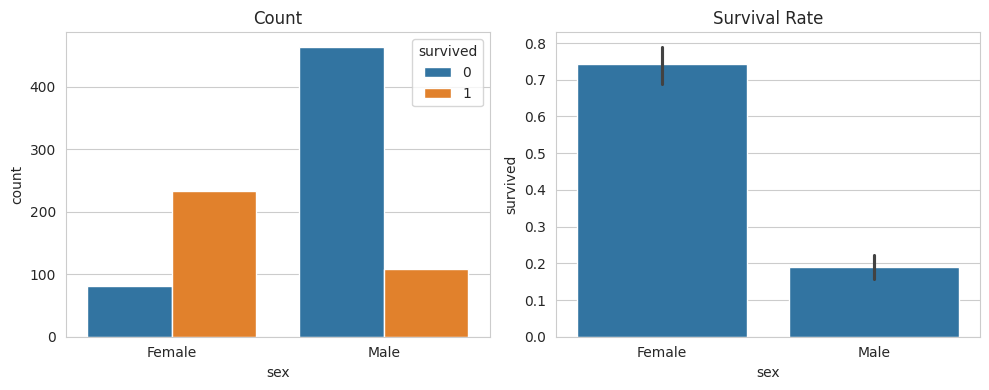

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='sex', hue='survived', data=df, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].set_title('Count')

sns.barplot(x='sex', y='survived', data=df, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Female', 'Male'])
axes[1].set_title('Survival Rate')

plt.tight_layout()
plt.show()

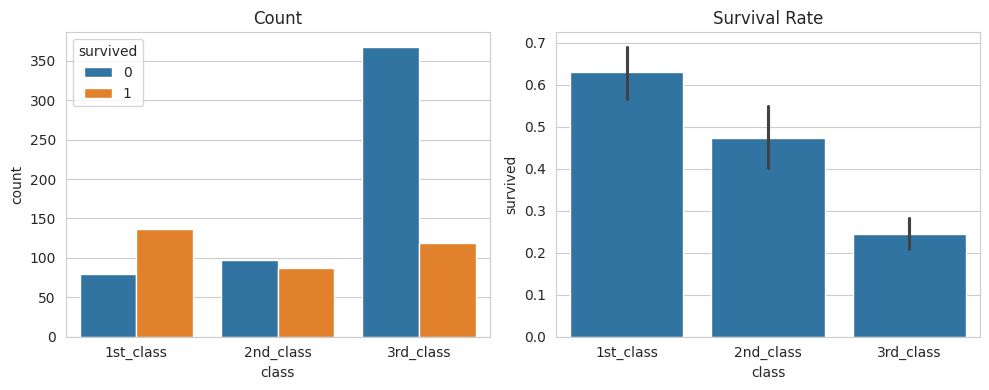

In [12]:
df['class'] = df[['1st_class', '2nd_class', '3rd_class']].idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='class', hue='survived', data=df, 
              order=['1st_class', '2nd_class', '3rd_class'], ax=axes[0])
axes[0].set_title('Count')

sns.barplot(x='class', y='survived', data=df,
            order=['1st_class', '2nd_class', '3rd_class'], ax=axes[1])
axes[1].set_title('Survival Rate')

plt.tight_layout()
plt.show()

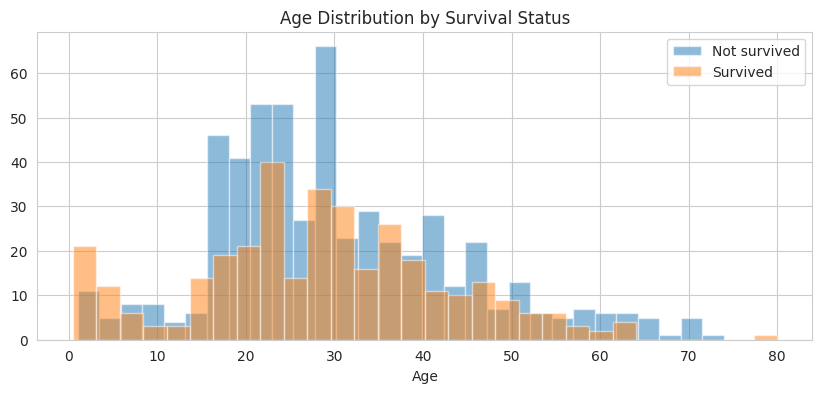

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

df[df['survived'] == 0]['age'].hist(bins=30, alpha=0.5, label='Not survived', ax=ax)
df[df['survived'] == 1]['age'].hist(bins=30, alpha=0.5, label='Survived', ax=ax)

ax.set_title('Age Distribution by Survival Status')
ax.set_xlabel('Age')
ax.legend()
plt.show()

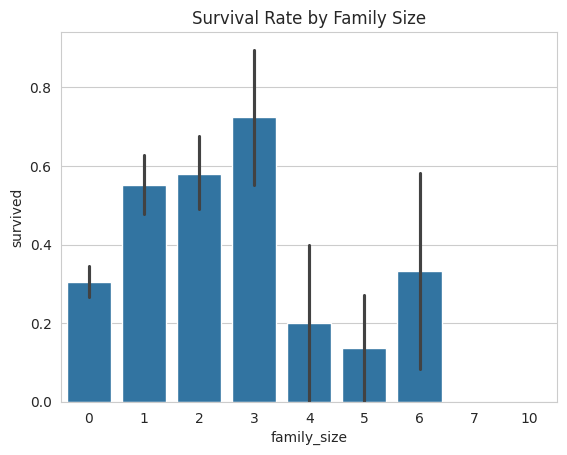

In [14]:
sns.barplot(x='family_size', y='survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

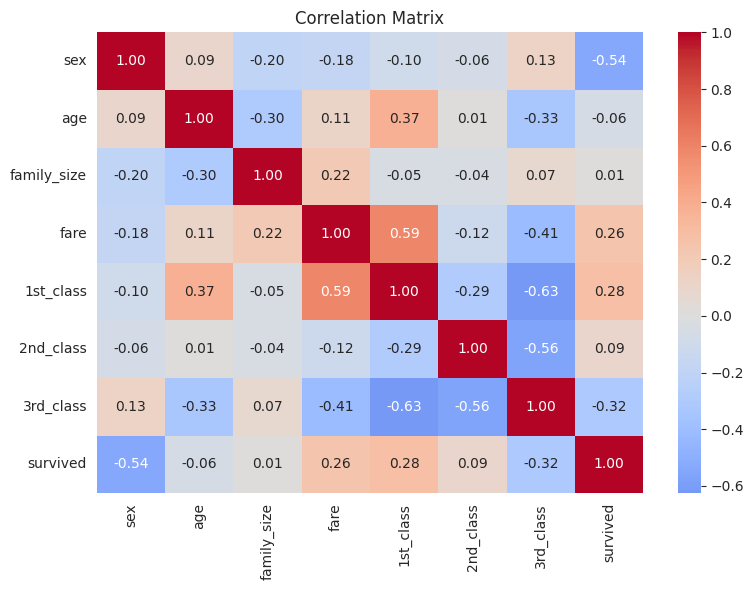

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

corr = df.drop(columns='class').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', 
            center=0, ax=ax)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

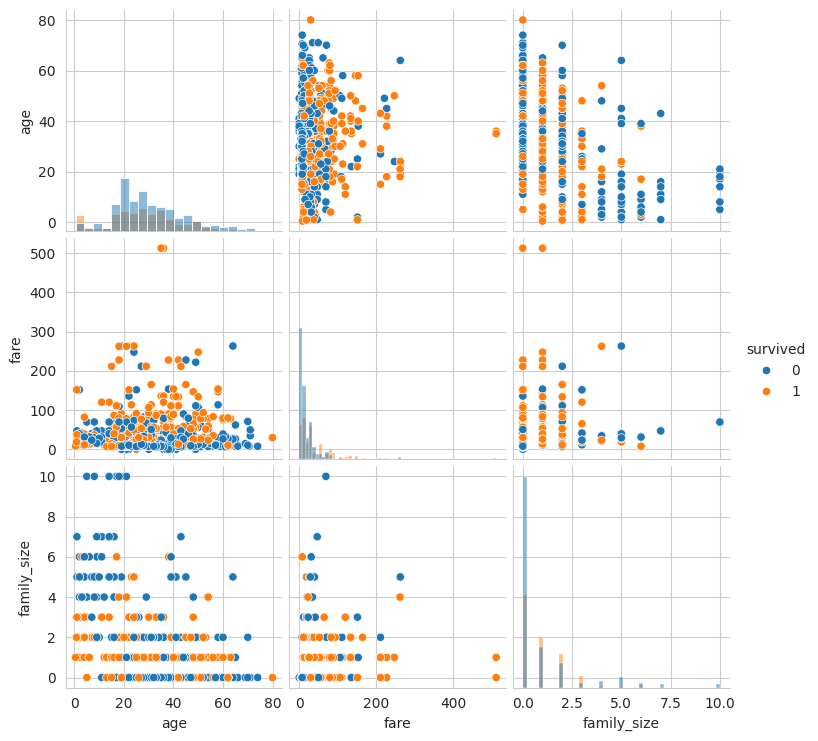

In [16]:
sns.pairplot(df[['age', 'fare', 'family_size', 'survived']], 
             hue='survived', diag_kind='hist', height=2.5)
plt.show()

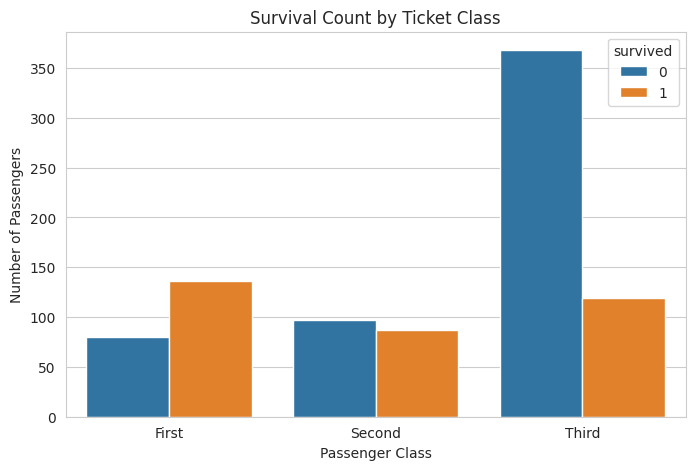

In [17]:
class_data = []
for index, row in df.iterrows():
    if row['1st_class'] == 1:
        class_data.append('First')
    elif row['2nd_class'] == 1:
        class_data.append('Second')
    else:
        class_data.append('Third')

df['Class_Group'] = class_data

# Plot the relationship
plt.figure(figsize=(8, 5))
sns.countplot(x='Class_Group', hue='survived', data=df, order=['First', 'Second', 'Third'])
plt.title('Survival Count by Ticket Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

#------------------------------------------------------------------------------------------------------------------------------

In [18]:
print(df['sex'].unique())
print(df['sex'].value_counts())
print(df['sex'].nunique())
print(df['family_size'].unique())
print(df['1st_class'].unique())
print(df['2nd_class'].unique())
print(df['3rd_class'].unique())
print(df['survived'].unique())

[1 0]
sex
1    573
0    314
Name: count, dtype: int64
2
[ 1  0  4  2  6  5  3  7 10]
[0 1]
[0 1]
[1 0]
[0 1]


<Axes: xlabel='sex', ylabel='count'>

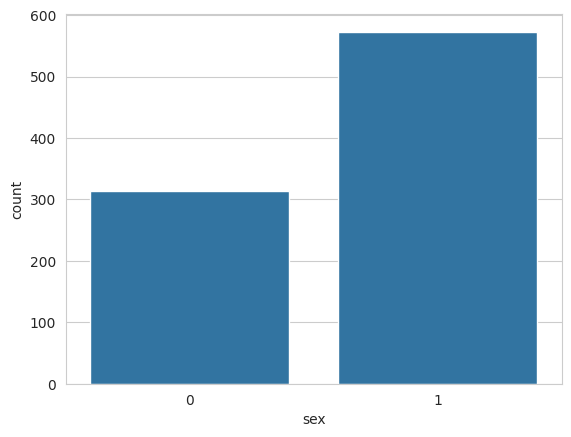

In [19]:
sns.countplot(x='sex', data=df)

<Axes: xlabel='survived', ylabel='count'>

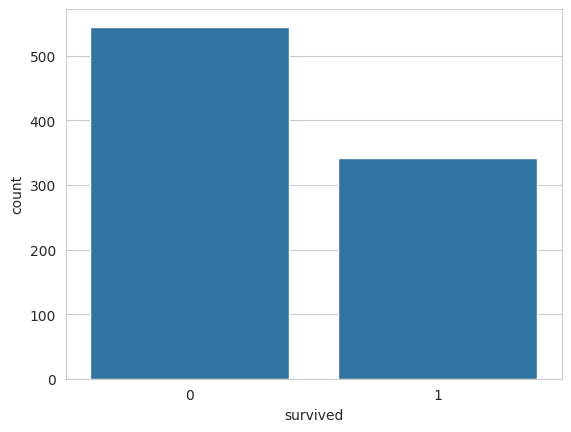

In [20]:
sns.countplot(x='survived', data=df)

<Axes: xlabel='survived', ylabel='count'>

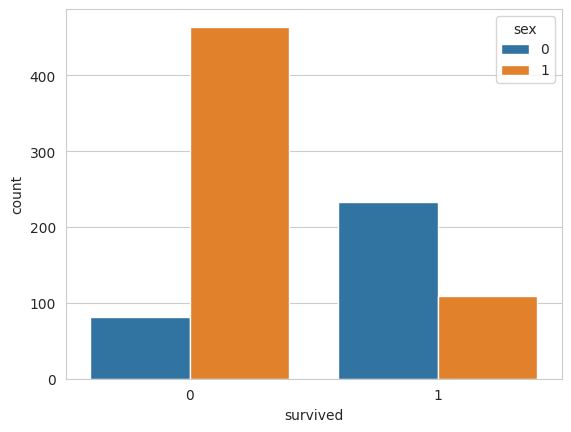

In [21]:
sns.countplot(x='survived', hue='sex', data=df)

<Axes: xlabel='sex', ylabel='survived'>

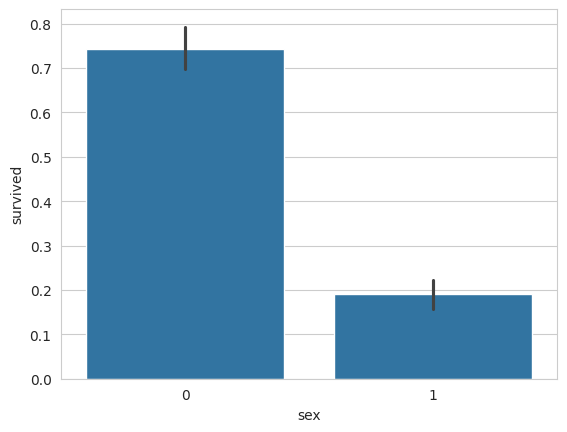

In [22]:
sns.barplot(x='sex', y='survived', data=df)

<Axes: xlabel='class', ylabel='survived'>

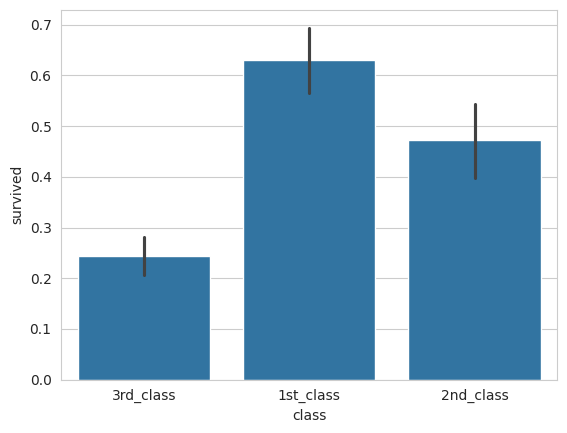

In [23]:
df['class'] = df[['1st_class','2nd_class','3rd_class']].idxmax(axis=1)
sns.barplot(x='class', y='survived', data=df)

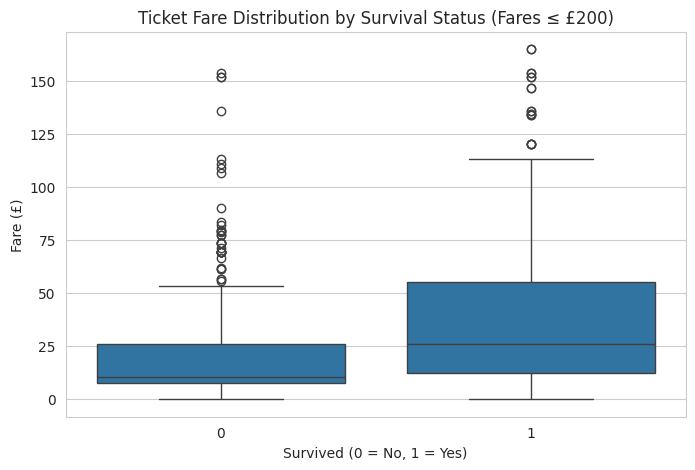

In [24]:
filtered_data = df[df['fare'] <= 200]

# 2. Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='survived', y='fare', data=filtered_data)

# 3. Make it readable
plt.title('Ticket Fare Distribution by Survival Status (Fares ≤ £200)')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare (£)')
plt.show()

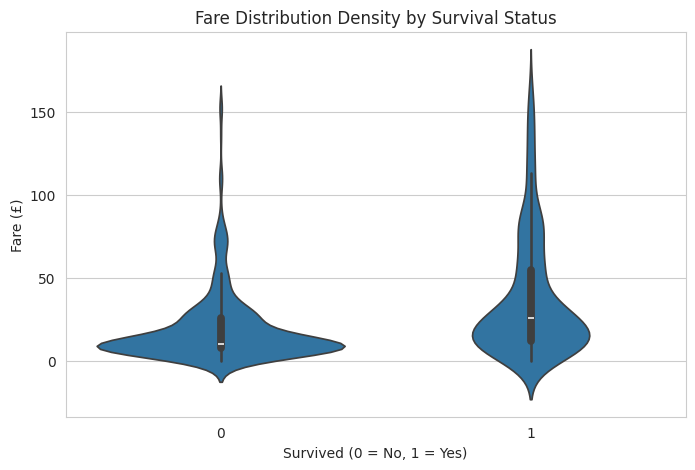

In [25]:
plt.figure(figsize=(8, 5))

# Create the violin plot using the filtered data
sns.violinplot(x='survived', y='fare', data=filtered_data)

plt.title('Fare Distribution Density by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare (£)')
plt.show()

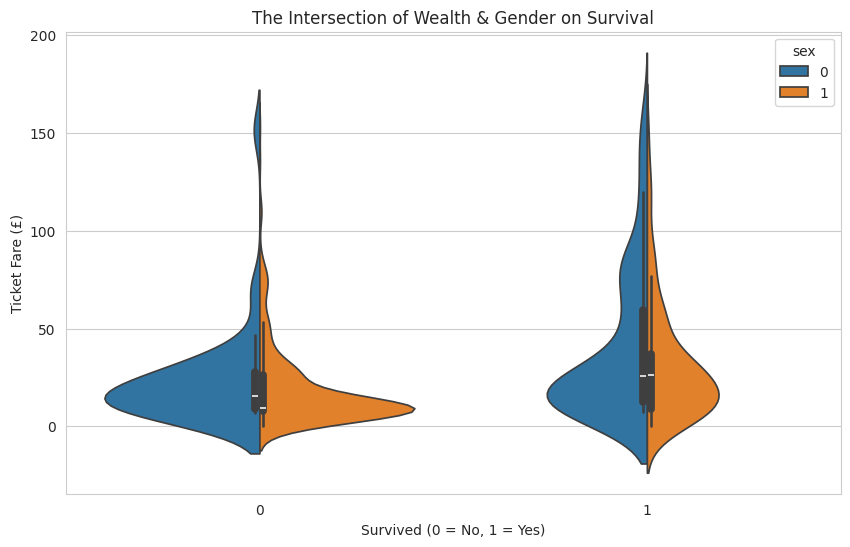

In [26]:
plt.figure(figsize=(10, 6))

# split=True merges the male/female data into a single violin per survival category
sns.violinplot(x='survived', y='fare', hue='sex', data=filtered_data, split=True)

plt.title('The Intersection of Wealth & Gender on Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (£)')
plt.show()

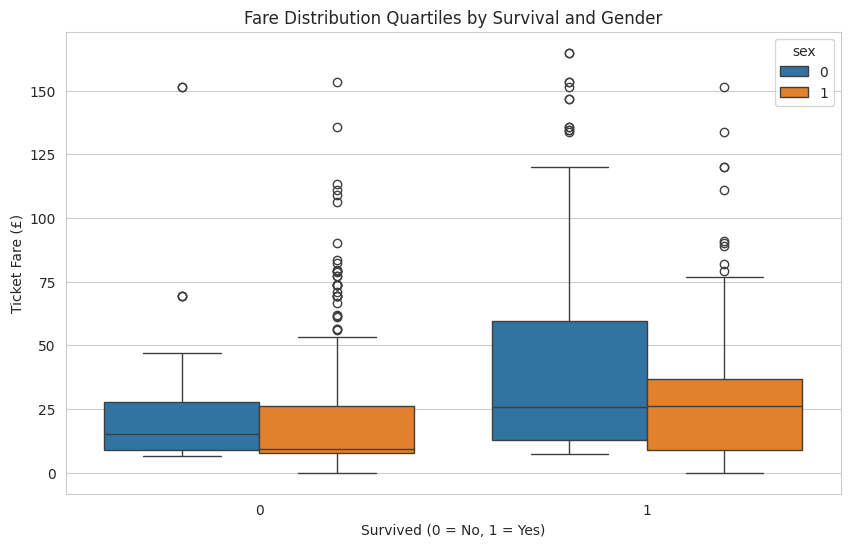

In [27]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='survived', y='fare', hue='sex', data=filtered_data)

plt.title('Fare Distribution Quartiles by Survival and Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (£)')
plt.show()

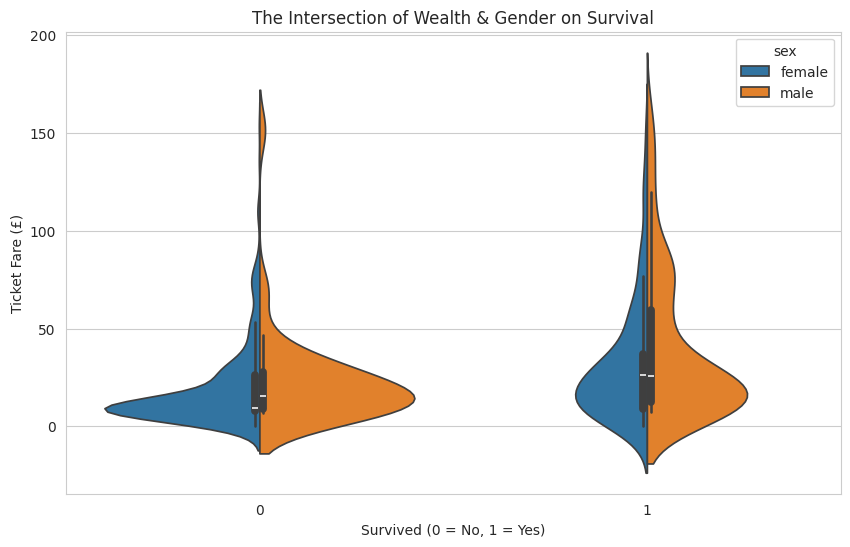

In [28]:
# Create a copy to avoid modifying your original data
plot_data = filtered_data.copy()

# Map the numeric codes back to readable categories
# (Assuming 0 is male and 1 is female based on Titanic data distributions)
plot_data['sex'] = plot_data['sex'].map({0: 'male', 1: 'female'})

# Re-run your plot code using the updated dataframe
plt.figure(figsize=(10, 6))
sns.violinplot(x='survived', y='fare', hue='sex', data=plot_data, split=True)

plt.title('The Intersection of Wealth & Gender on Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (£)')
plt.show()